<a href="https://colab.research.google.com/github/AliHamza700/Learning-Python/blob/main/model_generalization_and_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

df=pd.read_csv("/content/heart.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### ***`Part 1:Exploratory Data Analysis`***

In [6]:
df.shape

(1025, 14)

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
df.duplicated().sum()

np.int64(723)

## ***Target Distribution Graph***

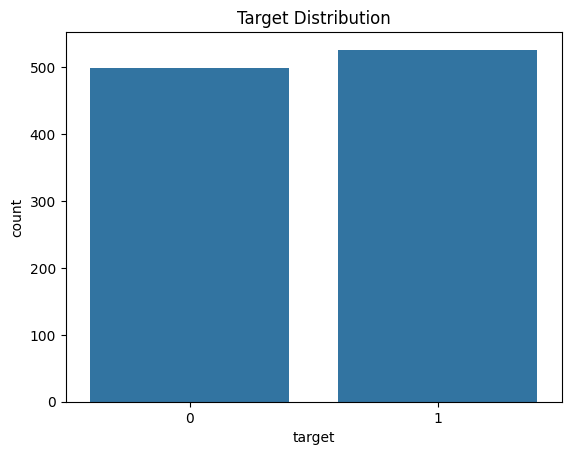

In [ ]:

sns.countplot(x='target', data=df)
plt.title('Target Distribution')
plt.show()

## ***Histograms of Numerical Variables***

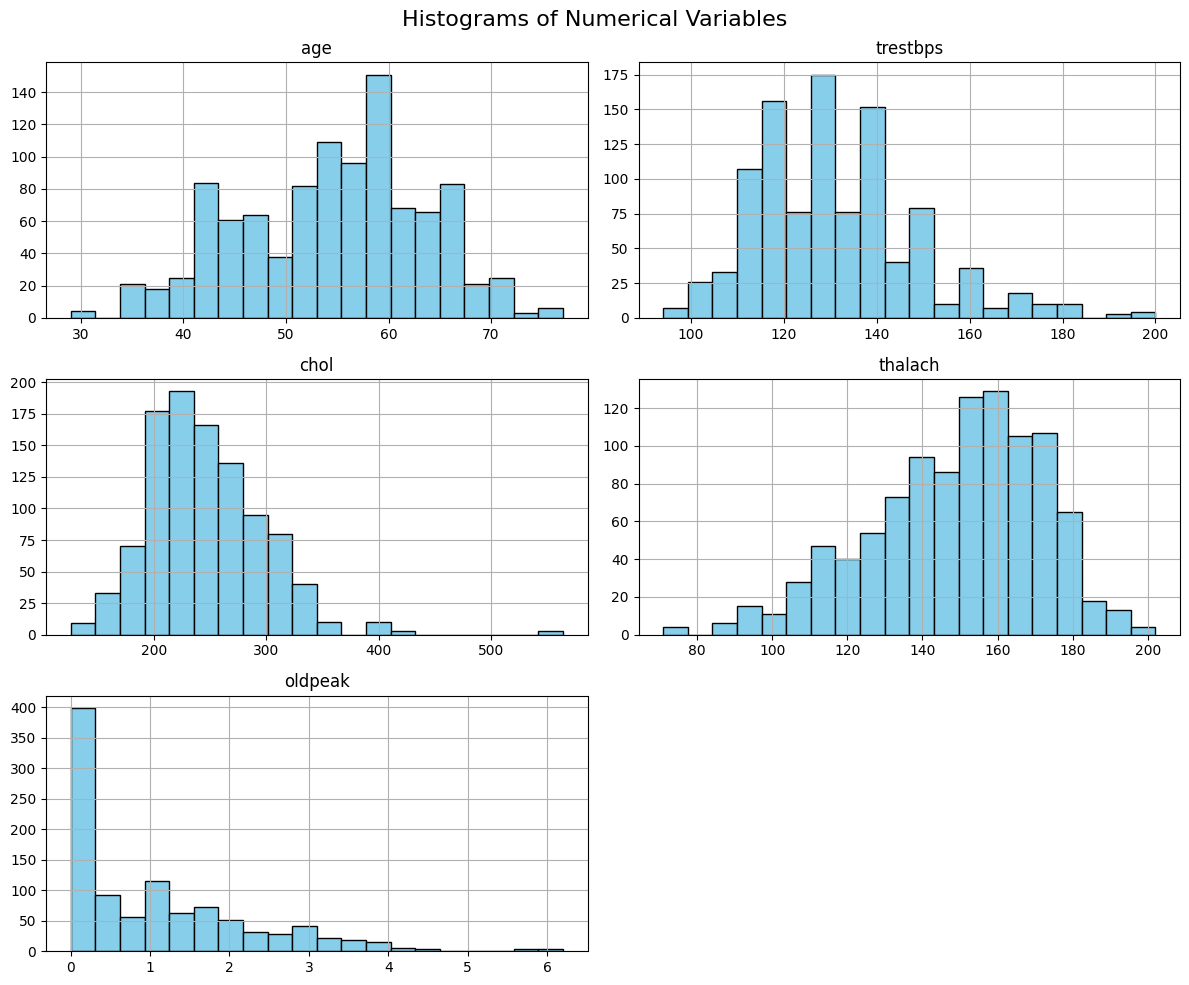

In [ ]:

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

df[numerical_cols].hist(figsize=(12, 10), bins=20, color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Variables', fontsize=16)
plt.tight_layout()
plt.show()

## ***Correlation Heatmap***

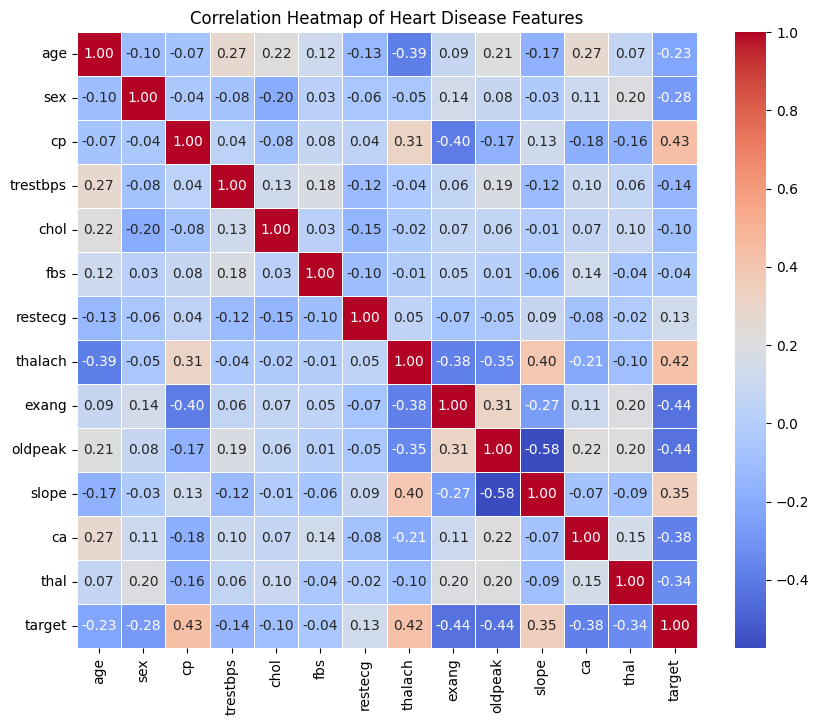

In [ ]:
plt.figure(figsize=(10, 8))


corr_matrix = df.corr()


sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Heart Disease Features')
plt.show()

## ***Feature Distributions Grouped by Target***

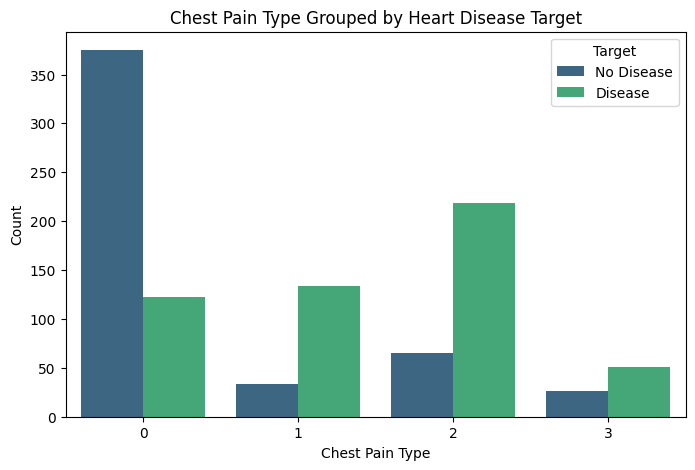

In [ ]:

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='cp', hue='target', palette='viridis')

plt.title('Chest Pain Type Grouped by Heart Disease Target')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Target', labels=['No Disease', 'Disease'])
plt.show()

## ***Deliverables***
**# Is the dataset balanced?**

Yes,
nearly balanced. 526 (51.3%) with heart disease vs 499 (48.7%) without. No balancing needed.

# **Which features appear important?**
 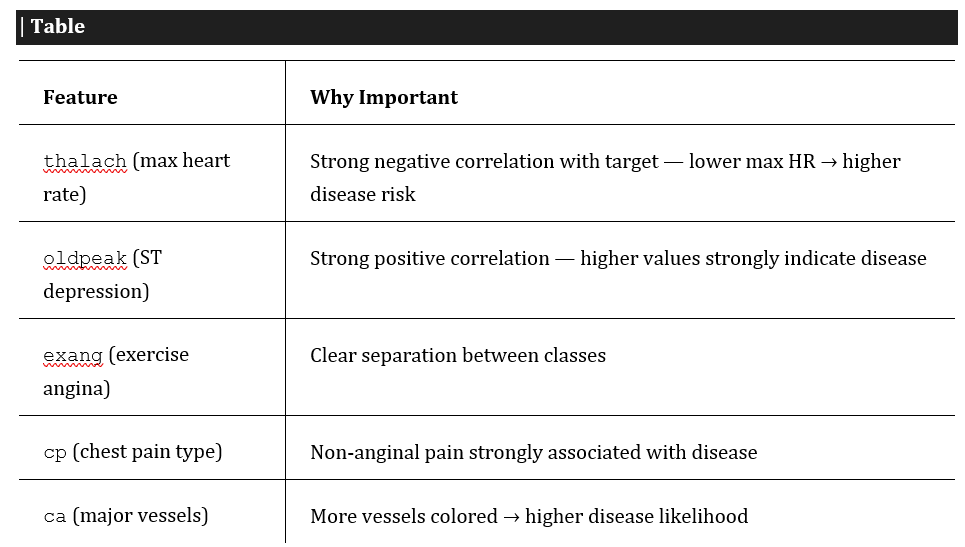

 #Are *preprocessing steps required?*

Yes:
Categorical encoding for sex, cp, fbs, restecg, exang, slope, ca, thal
Numerical scaling for age, trestbps, chol, thalach, oldpeak

###  **Part 2: Data Preparation**

In [10]:
x=df.drop('target',axis=1)
y=df['target']


## ***StandardScaler***

In [11]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

## ***MinMaxScaler***

In [14]:
scaler = MinMaxScaler()
x_scaled = scaler.fit_transform(x)

## Split Data

In [16]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x_scaled,y,test_size=0.30,random_state=42)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,y_temp,test_size=0.50,random_state=42)